# Défi ÉquiAlgo - analyse par tranches

Trois découpages : **région** (5 régions), **cote R** (7 tranches) et **revenu familial** (quintiles
calculés sur `train`). Les tranches de cote R et de revenu sont croisees avec le groupe
(Centre / Eloignee).

- **Partie A, entraînement** : y_true est la nouvelle cible (`cible.cible_individuelle`). On la compare,
  dans chaque tranche, à la décision du comité (`decision_octroi`) et aux prédictions des deux modèles.
- **Partie B, test** : métriques par tranche du RF de production et du modèle corrigé, contre y_true de
  test, la nouvelle cible binarisée (40 % meilleurs scores de `cible.score_merite`, voir
  `model_corrige.ipynb` §1.5).

Même découpage 70/30 que la baseline (stratifié, `random_state=42`).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from analyse.analyse import tableau_tranches
from cible import (VARIABLES_MODELE, ajouter_eloignee, ajuster_modele_decision, cible_individuelle,
                   entrainer_modele_cible, octroi_top_k, score_merite)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

demandes = ajouter_eloignee(pd.read_csv('data/donnees_demandes.csv'))
demandes['groupe'] = np.where(demandes['eloignee'] == 1, 'Eloignee', 'Centre')
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)

# y_true = nouvelle cible, a partir du modele de decision de train :
# souple sur train (cible individuelle), binarisee sur test (40 % meilleurs scores de merite).
modele_valid = ajuster_modele_decision(train)
y_true_tr = cible_individuelle(modele_valid, train)
y_ref = octroi_top_k(score_merite(modele_valid, test, reference=train))

# Modele de production (RF de la baseline) et modele corrige, ajustes sur train.
CATEGORIELLES_RF = ['programme_etudes', 'region_administrative', 'code_postal_3']
retirer = ['id_candidat', 'decision_octroi', 'eloignee', 'groupe']
X_tr = pd.get_dummies(train.drop(columns=retirer), columns=CATEGORIELLES_RF)
X_te = pd.get_dummies(test.drop(columns=retirer), columns=CATEGORIELLES_RF).reindex(columns=X_tr.columns, fill_value=0)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
rf.fit(X_tr, train['decision_octroi'])
modele_corrige = entrainer_modele_cible(train, y_true_tr)

# Partie A : probabilites predites sur train. Partie B : decisions sur test (40 % pour le modele corrige).
proba_tr = {'RF de production': rf.predict_proba(X_tr)[:, 1],
            'modele corrige': modele_corrige.predict_proba(train[VARIABLES_MODELE])[:, 1]}
decisions = {
    'RF de production': rf.predict(X_te),
    'modele corrige': octroi_top_k(modele_corrige.predict_proba(test[VARIABLES_MODELE])[:, 1]),
}

# Palette de reference : Centre bleu, Eloignee orange ; textes en encre neutre.
COULEURS_GROUPE = {'Centre': '#2a78d6', 'Eloignee': '#eb6834'}
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'


def styliser(ax, titre=None):
    """Axes discrets : grille legere, sans cadre haut/droite."""
    if titre:
        ax.set_title(titre, color=ENCRE, fontsize=11, loc='left')
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)
    return ax

## Définition des tranches

Les bornes de revenu sont les quintiles de `train`, appliquées telles quelles à `test` : une tranche
désigne la même plage de revenu dans les deux jeux.

In [ ]:
BORNES_R = [0, 26, 27, 28, 29, 30, 32, 45]
BORNES_REVENU = np.quantile(train['revenu_familial_estime'], [0, 0.2, 0.4, 0.6, 0.8, 1])
BORNES_REVENU[0], BORNES_REVENU[-1] = 0, np.inf
ETIQUETTES_REVENU = [f'Q{i + 1} {a / 1000:.0f}-{b / 1000:.0f}k' if np.isfinite(b) else f'Q{i + 1} {a / 1000:.0f}k+'
                     for i, (a, b) in enumerate(zip(BORNES_REVENU[:-1], BORNES_REVENU[1:]))]


def tranches(df):
    """Les trois decoupages d'un jeu de donnees, chacun pret pour un groupby ou un MetricFrame."""
    groupe = df['groupe'].rename('groupe')
    cote_r = pd.cut(df['cote_r_equivalent'], BORNES_R).astype(str).rename('cote R')
    revenu = pd.cut(df['revenu_familial_estime'], BORNES_REVENU, labels=ETIQUETTES_REVENU).astype(str).rename('revenu')
    return {
        'region': df['region_administrative'].rename('region'),
        'cote R': pd.concat([cote_r, groupe], axis=1),
        'revenu': pd.concat([revenu, groupe], axis=1),
    }


tranches_tr, tranches_te = tranches(train), tranches(test)
print('Quintiles de revenu (train) :', ETIQUETTES_REVENU)

Quintiles de revenu (train) : ['Q1 0-42k', 'Q2 42-55k', 'Q3 55-69k', 'Q4 69-90k', 'Q5 90k+']


## Partie A - Entraînement : y_true contre le comité et les modèles

**y_true est la nouvelle cible** (`cible.cible_individuelle`). Elle part de la décision du comité et la
corrige dossier par dossier : pénalité régionale retirée, revenu et distance neutralisés. Avec p la
probabilité d'octroi du comité et q le score de mérite :
- un dossier accordé par le comité reçoit min(1, q / p) : y_true baisse si le revenu l'avait aidé ;
- un dossier refusé reçoit max(0, (q - p) / (1 - p)) : y_true monte s'il avait été pénalisé.

Par tranche, on compare la moyenne de y_true :
- au taux d'octroi du **comité** (`decision_octroi`) : ce que la cible corrige ;
- à la probabilité moyenne prédite par les **deux modèles** sur `train` : le RF de production (entraîné
  sur `decision_octroi`) et le modèle corrigé (entraîné sur y_true). Le score de Brier, écart quadratique
  moyen entre la prédiction et y_true, mesure l'ajustement dans chaque tranche (0 = parfait).

In [ ]:
def comparer_a_y_true(df, y_true, proba, tranche):
    """Compare, par tranche, y_true, le comite et chaque modele.

    Le score de Brier est la moyenne de (probabilite predite - cible) ** 2 :
    plus il est bas, meilleures sont la calibration et la precision probabiliste.
    """
    donnees = pd.DataFrame({'y_true': np.asarray(y_true), 'comite': df['decision_octroi'].to_numpy(),
                            **{nom: np.asarray(p) for nom, p in proba.items()}}, index=df.index)
    cles = [tranche[c] for c in tranche.columns] if isinstance(tranche, pd.DataFrame) else [tranche]
    par_tranche = donnees.groupby(cles, observed=True)
    moyennes = par_tranche.mean()
    tableau = pd.DataFrame({'effectif': par_tranche.size(), 'y_true': moyennes['y_true'],
                            'comite': moyennes['comite']})
    for nom in proba:
        tableau[nom] = moyennes[nom]
    # Ecarts de taux par rapport a la cible de reference y_true.
    tableau['ecart comite vs y_true'] = moyennes['comite'] - moyennes['y_true']
    for nom in proba:
        tableau[f'ecart {nom} vs y_true'] = moyennes[nom] - moyennes['y_true']
        tableau[f'ecart {nom} vs comite'] = moyennes[nom] - moyennes['comite']
        tableau[f'Brier {nom}'] = ((donnees[nom] - donnees['y_true']) ** 2).groupby(cles, observed=True).mean()
    return tableau


comparaisons_tr = {nom: comparer_a_y_true(train, y_true_tr, proba_tr, t) for nom, t in tranches_tr.items()}
for nom, tableau in comparaisons_tr.items():
    print(f'--- {nom} ---')
    print(tableau.round(3), end='\n\n')

--- region ---
                               effectif  y_true  comite  RF de production  modele corrige  ecart comite  ecart RF de production  Brier RF de production  ecart modele corrige  Brier modele corrige
region                                                                                                                                                                                             
Bas-Saint-Laurent                   893   0.459   0.281             0.284           0.461        -0.177                  -0.175                   0.083                 0.002                 0.008
Capitale-Nationale                 1388   0.480   0.483             0.480           0.479         0.003                  -0.000                   0.064                -0.001                 0.056
Cote-Nord                           814   0.461   0.260             0.268           0.460        -0.201                  -0.193                   0.093                -0.001                 0.012
Gaspe

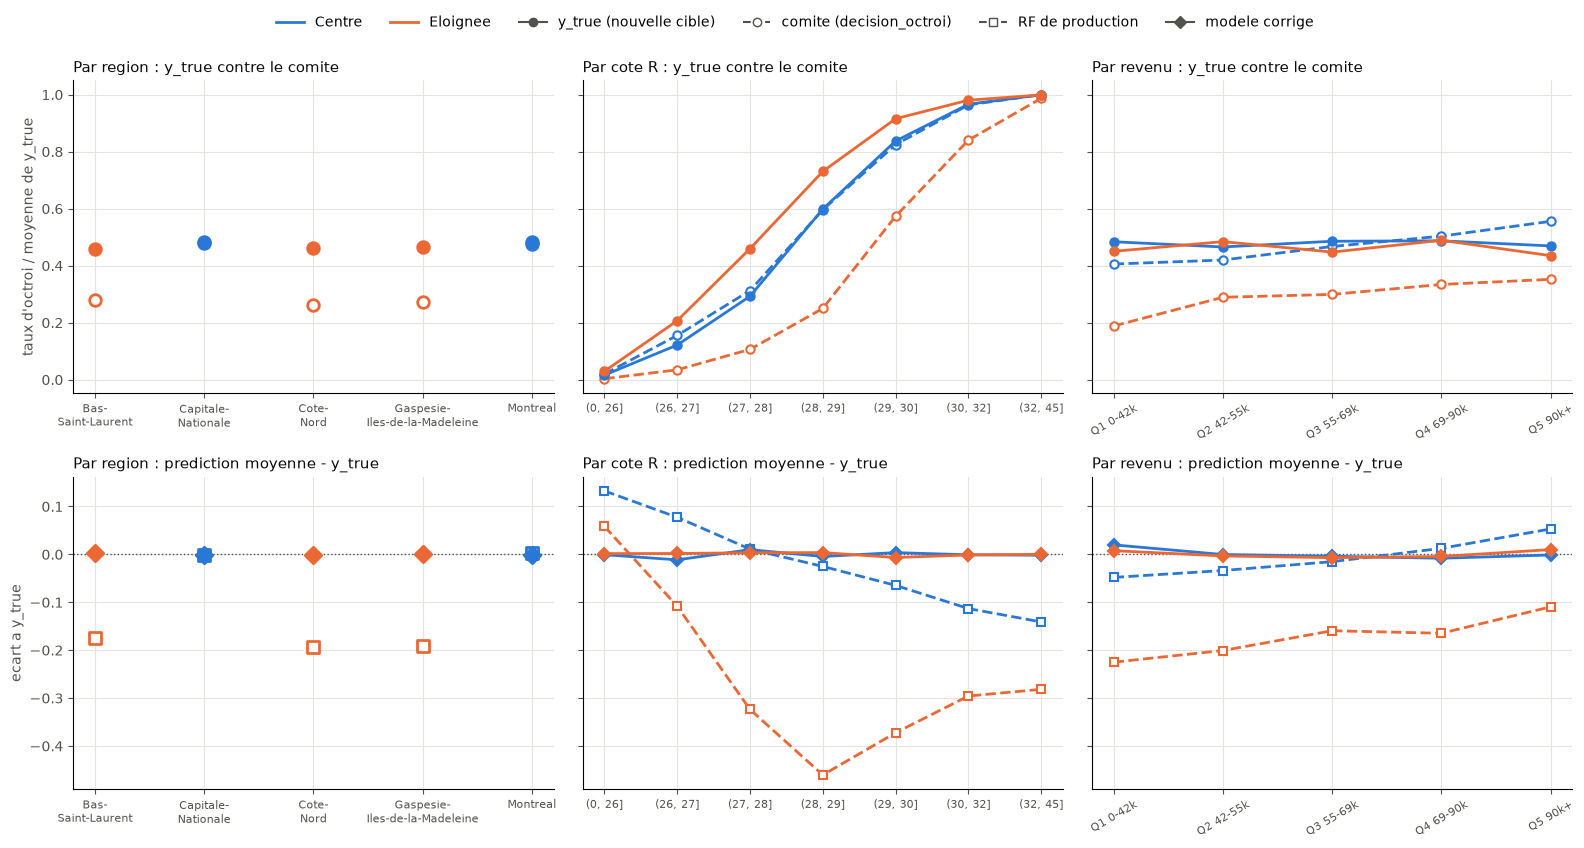

In [ ]:
def tracer_series(ax, tableau, nom, series):
    """Trace des colonnes de `tableau` par tranche : une couleur par groupe, un style par serie."""
    if tableau.index.nlevels == 1:
        # Region : une tranche = une region, coloree selon son groupe.
        groupes = train.groupby('region_administrative')['groupe'].first().reindex(tableau.index)
        x = np.arange(len(tableau))
        for colonne, style, plein in series:
            for g, couleur in COULEURS_GROUPE.items():
                m = (groupes == g).to_numpy()
                ax.scatter(x[m], tableau[colonne][m], s=70, marker=style[-1], lw=2, zorder=3,
                           facecolor=couleur if plein else 'white', edgecolor=couleur)
        ax.set_xticks(x, [r.replace('-', '-\n', 1) for r in tableau.index], fontsize=8)
    else:
        niveaux = tableau.index.get_level_values(0).unique()
        x = np.arange(len(niveaux))
        for colonne, style, plein in series:
            for g, couleur in COULEURS_GROUPE.items():
                t = tableau.xs(g, level='groupe').reindex(niveaux)
                ax.plot(x, t[colonne], style, color=couleur, lw=2, ms=6, mew=1.5,
                        mfc=couleur if plein else 'white', mec=couleur)
        ax.set_xticks(x, niveaux, fontsize=8, rotation=30 if nom == 'revenu' else 0)


def tracer_comparaisons(comparaisons):
    """Ligne 1 : y_true contre le comite. Ligne 2 : ecart de prediction de chaque modele a y_true."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharey='row')
    for (ax_haut, ax_bas), (nom, tableau) in zip(axes.T, comparaisons.items()):
        tracer_series(ax_haut, tableau, nom, [('comite', '--o', False), ('y_true', '-o', True)])
        styliser(ax_haut, f'Par {nom} : y_true contre le comite')
        ax_bas.axhline(0, color=ENCRE_SECONDAIRE, lw=1, ls=':')
        tracer_series(ax_bas, tableau, nom, [('ecart RF de production vs y_true', '--s', False),
                                             ('ecart modele corrige vs y_true', '-D', True)])
        styliser(ax_bas, f'Par {nom} : prediction moyenne - y_true')
    axes[0, 0].set_ylabel("taux d'octroi / moyenne de y_true", color=ENCRE_SECONDAIRE)
    axes[1, 0].set_ylabel('ecart a y_true', color=ENCRE_SECONDAIRE)
    legende = [plt.Line2D([], [], color=c, lw=2, label=g) for g, c in COULEURS_GROUPE.items()]
    legende += [
        plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='-', marker='o', label='y_true (nouvelle cible)'),
        plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='--', marker='o', mfc='white', label='comite (decision_octroi)'),
        plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='--', marker='s', mfc='white', label='RF vs y_true'),
        plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='-', marker='D', label='modele corrige vs y_true'),
    ]
    fig.legend(handles=legende, loc='upper center', ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.0))
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


tracer_comparaisons(comparaisons_tr)

**Lecture.**

*y_true contre le comité (ligne du haut).*
- **Région** : y_true dépasse le taux du comité de 18 à 20 points dans chacune des trois régions
  éloignées (Bas-Saint-Laurent : 46 % contre 28 % ; Côte-Nord : 46 % contre 26 % ; Gaspésie : 47 % contre
  27 %), et s'en écarte de moins d'un point au Centre. Après correction, l'écart entre les deux blocs
  n'est plus que de 1 à 2 points.
- **Cote R** : en région, la correction est la plus forte près du seuil : +48 points entre 28 et 29 (73 %
  contre 25 %), +34 à +35 points dans les tranches voisines. Au Centre, y_true reste à moins de
  3.5 points du comité. À cote R égale, les candidats éloignés passent devant (73 % contre 60 % entre 28
  et 29) : l'étalon valorise les heures travaillées, plus nombreuses en région.
- **Revenu** : la pente de revenu du comité disparaît. Au Centre, le comité passe de 41 % (Q1) à 56 %
  (Q5), y_true reste entre 47 et 49 % ; en région, le comité passe de 19 à 35 %, y_true reste entre 43
  et 49 %.

*Prédictions contre y_true (ligne du bas).*
- **Le RF de production reproduit le comité, pas y_true.** Il sous-estime y_true de 17 à 19 points dans
  chaque région éloignée, autant que le comité, et de 46 points entre 28 et 29 de cote R. Par revenu, il
  garde la pente du comité : au Centre, son écart passe de -5 points (Q1) à +5 points (Q5). Il lisse
  aussi les extrêmes de cote R (+13 points sous 26 et -14 points au-dessus de 32 au Centre), effet de
  ses feuilles d'au moins 20 dossiers.
- **Le modèle corrigé est calibré dans chaque tranche** : sa prédiction moyenne reste à moins de
  2 points de y_true partout, y compris dans les tranches où le RF s'en écarte le plus.
- **Brier** : celui du modèle corrigé est nettement plus bas en région (0.002 à 0.025, contre 0.008 à
  0.24 pour le RF). Au Centre, les deux modèles sont proches (0.00 à 0.14), et le modèle corrigé est même
  très légèrement moins bon entre 27 et 30 de cote R (au plus 0.007 de plus). Ce n'est pas un biais : au
  Centre, y_true garde les décisions tranchées du comité (0 ou 1), dont une partie ne s'explique par
  aucune variable. En région, y_true est une probabilité lissée, plus facile à prédire.
- Les prédictions sont faites sur `train`, les données d'entraînement : le RF, plus flexible, y est
  avantagé.

### Distribution des trois y

Sur `train`, par groupe, la distribution de chacun des trois y :
- **décision du comité** (`decision_octroi`) : binaire, 0 ou 1 ;
- **y_true** (nouvelle cible) : probabilité entre 0 et 1 ;
- **y_proba** : probabilité d'octroi prédite par le modèle corrigé, entraîné sur y_true.

                                   moyenne  ecart-type    q10  mediane    q90  part = 0  part = 1  part > 0.5
decision du comite       Centre      0.484       0.500  0.000    0.000  1.000     0.516     0.484       0.484
                         Eloignee    0.271       0.445  0.000    0.000  1.000     0.729     0.271       0.271
y_true (nouvelle cible)  Centre      0.478       0.466  0.000    0.286  1.000     0.268     0.272       0.473
                         Eloignee    0.462       0.413  0.003    0.355  1.000     0.063     0.270       0.447
y_proba (modele corrige) Centre      0.477       0.403  0.004    0.428  0.994     0.050     0.041       0.474
                         Eloignee    0.463       0.399  0.004    0.393  0.991     0.053     0.041       0.460


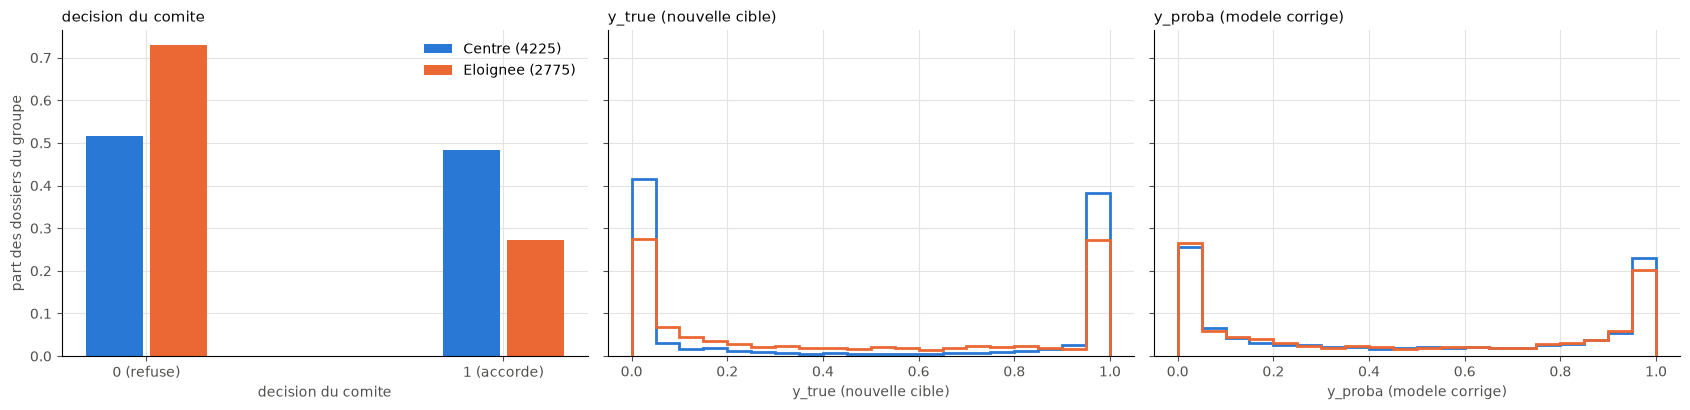

In [ ]:
groupe_tr = train['groupe'].to_numpy()
trois_y = {
    'decision du comite': train['decision_octroi'].to_numpy(),
    'y_true (nouvelle cible)': y_true_tr,
    'y_proba (modele corrige)': proba_tr['modele corrige'],
}


def resumer(valeurs):
    """Statistiques de distribution d'une variable entre 0 et 1."""
    s = pd.Series(valeurs)
    return {'moyenne': s.mean(), 'ecart-type': s.std(), 'q10': s.quantile(0.1), 'mediane': s.median(),
            'q90': s.quantile(0.9), 'part = 0': (s < 1e-3).mean(), 'part = 1': (s > 1 - 1e-3).mean(),
            'part > 0.5': (s > 0.5).mean()}


print(pd.DataFrame({(nom, g): resumer(y[groupe_tr == g])
                    for nom, y in trois_y.items() for g in COULEURS_GROUPE}).T.round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True)
bacs = np.linspace(0, 1, 21)
largeur = bacs[1] - bacs[0]
for ax, (nom, y) in zip(axes, trois_y.items()):
    for i, (g, couleur) in enumerate(COULEURS_GROUPE.items()):
        valeurs = y[groupe_tr == g]
        if nom == 'decision du comite':
            # Variable binaire : barres cote a cote a 0 et a 1.
            parts = [(valeurs == 0).mean(), (valeurs == 1).mean()]
            ax.bar(np.array([0, 1]) + (i - 0.5) * 0.18, parts, width=0.16, color=couleur,
                   label=f'{g} ({len(valeurs)})')
        else:
            poids = np.full(len(valeurs), 1 / len(valeurs))
            ax.hist(valeurs, bins=bacs, weights=poids, histtype='step', lw=2, color=couleur,
                    label=f'{g} ({len(valeurs)})')
    if nom == 'decision du comite':
        ax.set_xticks([0, 1], ['0 (refuse)', '1 (accorde)'])
    ax.set_xlabel(nom, color=ENCRE_SECONDAIRE)
    styliser(ax, nom)
axes[0].set_ylabel('part des dossiers du groupe', color=ENCRE_SECONDAIRE)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

**Lecture.**
- **Décision du comité** : binaire. Le comité a accordé la bourse à 48.4 % des dossiers du Centre
  contre 27.1 % des dossiers éloignés : un écart de 21 points.
- **y_true** : bimodale, avec des pics à 0 et à 1 et une masse intermédiaire, là où la cible corrige la
  décision du comité. Les moyennes se rapprochent (47.8 % contre 46.2 %, soit 1.6 point d'écart). Les
  formes restent différentes : au Centre, 27 % des dossiers sont exactement à 0 (refusés que rien ne
  corrige), contre 6 % seulement en région, où presque chaque refus reçoit une part de correction.
- **y_proba** : les distributions des deux groupes sont presque superposées (moyennes de 47.7 % et
  46.3 %, médianes de 0.43 et 0.39, 47.4 % et 46.0 % au-dessus de 0.5). Le modèle, qui ne voit ni la
  région ni ses proxys, attribue des probabilités semblables aux deux groupes.
- y_proba est moins tranchée que y_true : 4 à 5 % des dossiers seulement sont à 0 ou à 1. Le modèle
  prédit le mérite attendu à partir des variables, pas la décision individuelle du comité ; la part de
  ses décisions qu'aucune variable n'explique se moyenne.
- De la décision du comité à y_proba, l'écart moyen entre les groupes passe de 21 points à 1.4 point.

## Partie B - Test : métriques par tranche

Métriques contre y_true de test (la nouvelle cible binarisée), pour les deux modèles. La TPR d'une tranche sans méritant
et la FPR d'une tranche sans non-méritant sont laissées vides. Les tranches de moins de 100 dossiers
sont signalées par `*`.

In [ ]:
def comparer_modeles(tranche):
    """Metriques completes par tranche, RF de production et modele corrige cote a cote."""
    tableau = pd.concat({nom: tableau_tranches(y_ref, d, tranche, complet=True) for nom, d in decisions.items()},
                        axis=1)
    effectif = tableau[('RF de production', 'effectif')]
    tableau = tableau.drop(columns=[('modele corrige', 'effectif'), ('modele corrige', 'meritants')])
    tableau[('', 'faible effectif')] = np.where(effectif < 100, '*', '')
    return tableau


metriques_tranches = {nom: comparer_modeles(t) for nom, t in tranches_te.items()}
for nom, tableau in metriques_tranches.items():
    print(f'--- {nom} ---')
    print(tableau.round(3), end='\n\n')

--- region ---
                              RF de production                                                             modele corrige                                                   
                                      effectif meritants taux_selection    tpr    fpr precision exactitude taux_selection    tpr    fpr precision exactitude faible effectif
region                                                                                                                                                                      
Bas-Saint-Laurent                        400.0     150.0          0.272  0.727  0.000     1.000      0.898          0.375  1.000  0.000     1.000      1.000                
Capitale-Nationale                       611.0     242.0          0.458  0.983  0.114     0.850      0.925          0.398  1.000  0.003     0.996      0.998                
Cote-Nord                                364.0     147.0          0.261  0.646  0.000     1.000      0.857          0.40

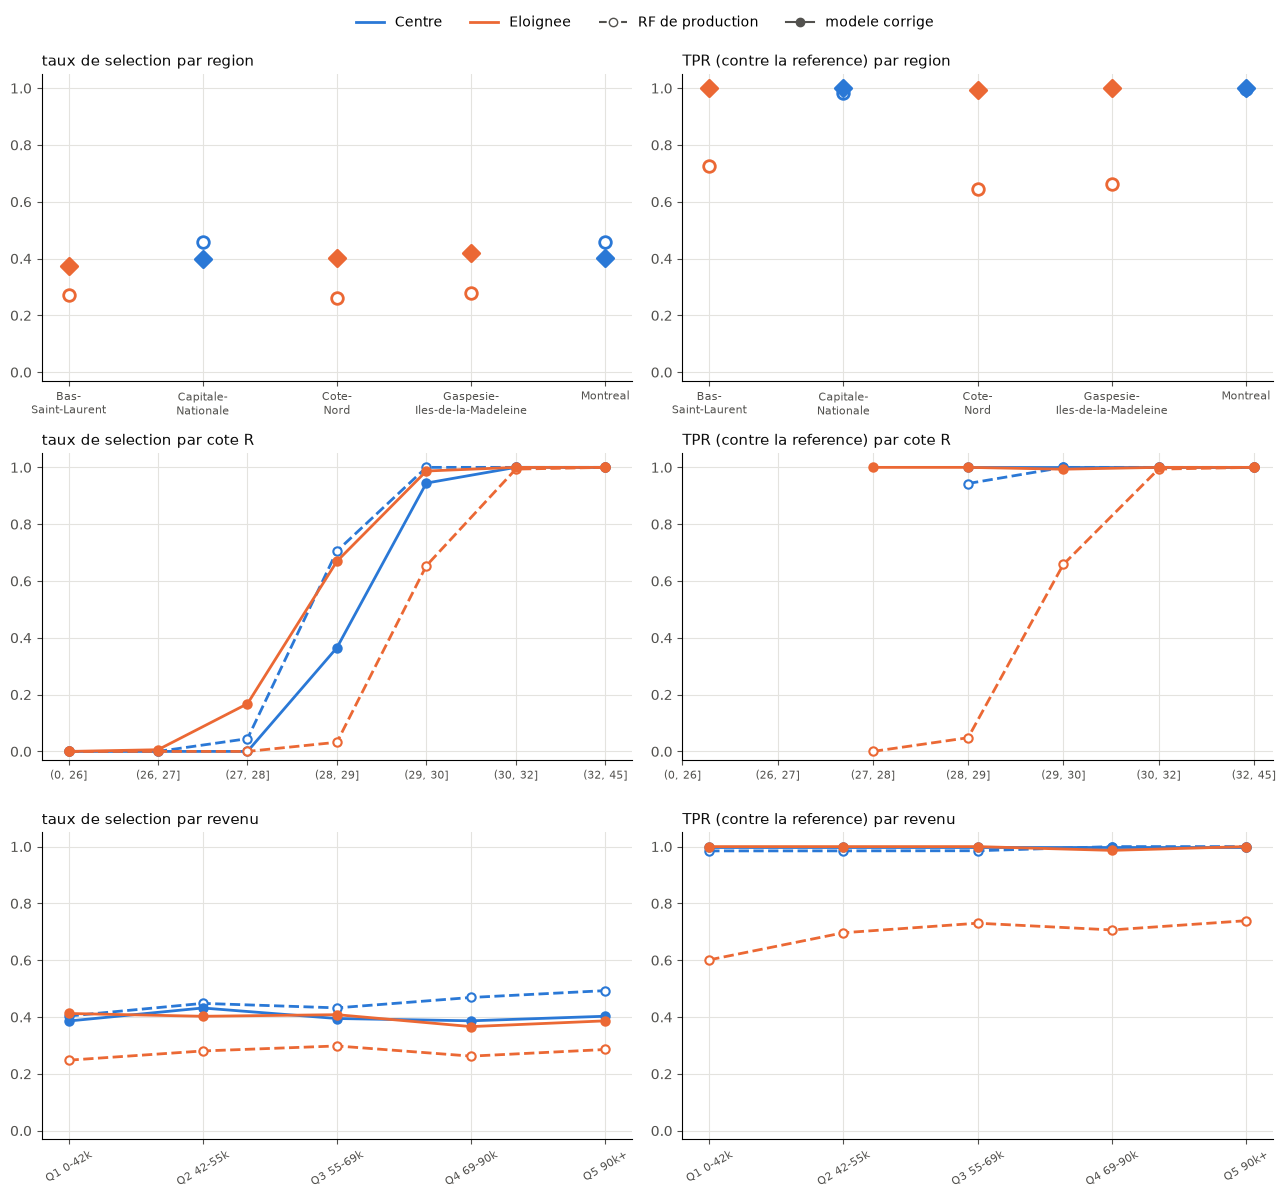

In [ ]:
def tracer_metriques(metriques_tranches, metriques=('taux_selection', 'tpr'), min_effectif=10):
    """Une ligne par decoupage, une colonne par metrique ; RF en pointille, modele corrige en trait plein."""
    titres = {'taux_selection': 'taux de selection', 'tpr': 'TPR (contre la reference)'}
    fig, axes = plt.subplots(len(metriques_tranches), len(metriques), figsize=(13, 4 * len(metriques_tranches)))
    for ligne, (nom, tableau) in zip(axes, metriques_tranches.items()):
        for ax, metrique in zip(ligne, metriques):
            if tableau.index.nlevels == 1:
                groupes = test.groupby('region_administrative')['groupe'].first().reindex(tableau.index)
                x = np.arange(len(tableau))
                for modele, forme in [('RF de production', 'o'), ('modele corrige', 'D')]:
                    for g, couleur in COULEURS_GROUPE.items():
                        m = (groupes == g).to_numpy()
                        plein = modele == 'modele corrige'
                        ax.scatter(x[m], tableau[(modele, metrique)][m], s=70, marker=forme,
                                   facecolor=couleur if plein else 'white', edgecolor=couleur, lw=2, zorder=3)
                ax.set_xticks(x, [r.replace('-', '-\n', 1) for r in tableau.index], fontsize=8)
            else:
                niveaux = tableau.index.get_level_values(0).unique()
                x = np.arange(len(niveaux))
                for g, couleur in COULEURS_GROUPE.items():
                    t = tableau.xs(g, level='groupe').reindex(niveaux)
                    for modele, style in [('RF de production', '--'), ('modele corrige', '-')]:
                        valeurs = t[(modele, metrique)].where(t[('RF de production', 'meritants')] >= min_effectif) \
                            if metrique == 'tpr' else t[(modele, metrique)]
                        ax.plot(x, valeurs, style + 'o', color=couleur, lw=2, ms=6,
                                mfc='white' if style == '--' else couleur, mec=couleur, mew=1.5)
                ax.set_xticks(x, niveaux, fontsize=8, rotation=30 if nom == 'revenu' else 0)
            ax.set_ylim(-0.03, 1.05)
            styliser(ax, f'{titres[metrique]} par {nom}')
    legende = [plt.Line2D([], [], color=c, lw=2, label=g) for g, c in COULEURS_GROUPE.items()]
    legende += [plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='--', marker='o', mfc='white', label='RF de production'),
                plt.Line2D([], [], color=ENCRE_SECONDAIRE, ls='-', marker='o', label='modele corrige')]
    fig.legend(handles=legende, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.0))
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


tracer_metriques(metriques_tranches)

**Lecture.** La référence de mérite et le modèle corrigé dérivent du même modèle de décision : la TPR
d'environ 1 du modèle corrigé est en partie **circulaire**. L'information se trouve surtout dans les
colonnes du RF de production ; pour un contrôle indépendant, voir `audit_rapport.ipynb` §5.

- **Région** : le RF à une TPR de 65 à 73 % dans chaque région éloignée, contre 98 à 100 % au Centre. A
  l'inverse, sà FPR est nulle en région et de 10 à 11 % au Centre (precision de 0.85 à 0.88) : il
  accordé des bourses à des candidats non méritants du Centre, au detriment de méritants éloignés.
  Après correction, la TPR est d'au moins 99.3 % et la FPR d'au plus 0.3 % partout.
- **Cote R** : entre 28 et 29, le RF accordé la bourse à 70.5 % des dossiers du Centre (FPR de 0.57)
  contre 3.2 % des dossiers éloignés (TPR de 0.05). Le modèle corrigé accordé à 36.5 % et 66.9 %.
- **Revenu** : la TPR du RF pour les candidats éloignés est de 60 à 74 % dans **tous** les quintiles, et
  la plus basse dans le plus pauvre (60 % en Q1) : les candidats éloignés et modestes cumulent les deux
  biais du comité. Au Centre, la FPR du RF augmente avec le revenu (de 4 % en Q1 à 15 % en Q5) : il
  accordé des bourses à des candidats aisés non méritants. Après correction, la TPR est d'au moins
  98.7 % partout, et les taux de sélection des deux groupes restent entre 37 et 43 % dans chaque
  quintile.